In [1]:
!nvidia-smi

Wed Mar 11 08:47:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   57C    P8             21W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip -q install -U transformers datasets peft trl accelerate bitsandbytes huggingface_hub matplotlib

In [3]:
import os
import torch
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
)
from peft import LoraConfig, get_peft_model
from trl import DPOTrainer, DPOConfig

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [4]:
dataset = load_dataset("jondurbin/truthy-dpo-v0.1")["train"]

split_dataset = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_dataset["train"]
eval_dataset = split_dataset["test"]

train_dataset_dpo = train_dataset.remove_columns(
    [c for c in train_dataset.column_names if c not in ["prompt", "chosen", "rejected"]]
)
eval_dataset_dpo = eval_dataset.remove_columns(
    [c for c in eval_dataset.column_names if c not in ["prompt", "chosen", "rejected"]]
)

print(train_dataset_dpo)
print(eval_dataset_dpo)
print(train_dataset_dpo[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 914
})
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 102
})
{'prompt': 'Did King Christian X of Denmark wear a yellow star to show solidarity with Jews during the Nazi occupation?', 'chosen': "No, King Christian X of Denmark did not wear a yellow star to show solidarity with Jews during the Nazi occupation. This misconception likely stems from a popular legend or story about the king's defiance against Nazi persecution of Jews. In reality, Jews in Denmark were never forced to wear the Star of David, and the Danish resistance played a crucial role in helping most Jews escape the country during the war.", 'rejected': "There is no definitive evidence that King Christian X of Denmark wore a yellow star to show solidarity with Jews during the Nazi occupation. However, it is a popular belief among Danes and has been widely reported in various sources.\n\nThe story goes that when the Nazis ordere

In [5]:
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=True)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("pad_token:", tokenizer.pad_token)
print("pad_token_id:", tokenizer.pad_token_id)

pad_token: <|endoftext|>
pad_token_id: 151643


In [6]:
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
)

ref_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map="auto",
)

model.config.pad_token_id = tokenizer.pad_token_id
model.config.use_cache = False

ref_model.config.pad_token_id = tokenizer.pad_token_id
ref_model.config.use_cache = False
ref_model.eval()

print("Policy model + reference model loaded.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Policy model + reference model loaded.


In [7]:
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)
model.gradient_checkpointing_enable()

peft_config = LoraConfig(
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


In [8]:
training_args = DPOConfig(
    output_dir="./qwen2.5-0.5b-truthy-dpo",
    num_train_epochs=1,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=1e-5,
    lr_scheduler_type="linear",
    warmup_ratio=0.1,
    logging_steps=10,
    eval_strategy="steps",
    eval_steps=40,
    save_strategy="steps",
    save_steps=40,
    save_total_limit=2,
    remove_unused_columns=False,
    gradient_checkpointing=True,
    fp16=False,
    bf16=False,
    max_length=384,
    beta=0.1,
    optim="paged_adamw_8bit",
    report_to="none",
    seed=42,
)

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [9]:
dpo_trainer = DPOTrainer(
    model=model,
    ref_model=ref_model,
    args=training_args,
    train_dataset=train_dataset_dpo,
    eval_dataset=eval_dataset_dpo,
    processing_class=tokenizer,
)

print("DPOTrainer created successfully.")

DPOTrainer created successfully.


In [10]:
train_result = dpo_trainer.train()
print(train_result)

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.


Step,Training Loss,Validation Loss
40,0.617418,0.616694
80,0.565358,0.566107


TrainOutput(global_step=115, training_loss=0.5940757150235383, metrics={'train_runtime': 531.0896, 'train_samples_per_second': 1.721, 'train_steps_per_second': 0.217, 'total_flos': 562671332889600.0, 'train_loss': 0.5940757150235383})


In [11]:
final_dir = "./qwen2.5-0.5b-truthy-dpo-final"

dpo_trainer.save_model(final_dir)
tokenizer.save_pretrained(final_dir)

print("Saved to:", final_dir)

Saved to: ./qwen2.5-0.5b-truthy-dpo-final


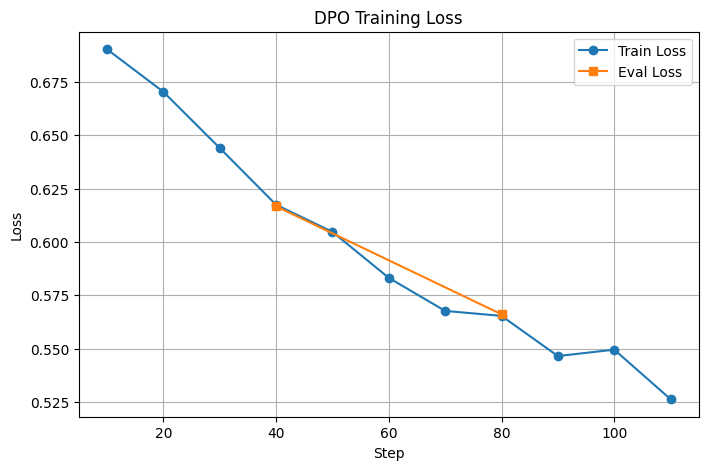

In [12]:
import matplotlib.pyplot as plt

log_history = dpo_trainer.state.log_history

train_steps = []
train_losses = []
eval_steps = []
eval_losses = []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_steps.append(log.get("step"))
        train_losses.append(log["loss"])
    if "eval_loss" in log:
        eval_steps.append(log.get("step"))
        eval_losses.append(log["eval_loss"])

plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_losses, marker="o", label="Train Loss")

if len(eval_steps) > 0:
    plt.plot(eval_steps, eval_losses, marker="s", label="Eval Loss")

plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("DPO Training Loss")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
!pip install huggingface_hub

In [19]:
from huggingface_hub import login
login()

In [21]:
from huggingface_hub import whoami
print(whoami())

{'type': 'user', 'id': '66a4e07f55a50dd32d6bfe34', 'name': 'annasus10', 'fullname': 'Thet Su Sann', 'email': 'thetsusann10@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1775001600, 'isPro': False, 'avatarUrl': 'https://cdn-avatars.huggingface.co/v1/production/uploads/no-auth/ajcK1YmlAtE2Ftw05Kudu.png', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'assignment5-token', 'role': 'write', 'createdAt': '2026-03-11T09:20:27.760Z'}}}


In [22]:
repo_name = "annasus10/qwen2.5-0.5b-truthy-dpo"

dpo_trainer.model.push_to_hub(repo_name)
tokenizer.push_to_hub(repo_name)

print("Pushed to:", repo_name)

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:  14%|#4        |  616kB / 4.35MB            

README.md: 0.00B [00:00, ?B/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...mpxwoovfal/tokenizer.json:  70%|######9   | 7.99MB / 11.4MB            

Pushed to: annasus10/qwen2.5-0.5b-truthy-dpo


In [23]:
from datasets import load_dataset

data_url = "https://huggingface.co/datasets/tatsu-lab/alpaca_eval/resolve/main/alpaca_eval.json"

dataset = load_dataset("json", data_files=data_url)

helpful_base_dataset = dataset["train"].filter(lambda x: x["dataset"] == "helpful_base")

print(helpful_base_dataset)
print(helpful_base_dataset[0])

alpaca_eval.json: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Filter:   0%|          | 0/805 [00:00<?, ? examples/s]

Dataset({
    features: ['dataset', 'instruction', 'output', 'generator'],
    num_rows: 129
})
{'dataset': 'helpful_base', 'instruction': 'What are the names of some famous actors that started their careers on Broadway?', 'output': 'Some famous actors that started their careers on Broadway include: \n1. Hugh Jackman \n2. Meryl Streep \n3. Denzel Washington \n4. Julia Roberts \n5. Christopher Walken \n6. Anthony Rapp \n7. Audra McDonald \n8. Nathan Lane \n9. Sarah Jessica Parker \n10. Lin-Manuel Miranda', 'generator': 'text_davinci_003'}


In [24]:
import random

random.seed(42)

sample_size = 15
indices = random.sample(range(len(helpful_base_dataset)), sample_size)
eval_samples = helpful_base_dataset.select(indices)

print("Number of evaluation samples:", len(eval_samples))
print(eval_samples[0])

Number of evaluation samples: 15
{'dataset': 'helpful_base', 'instruction': 'Why is kobe beef so damn expensive?', 'output': 'Kobe beef is expensive because it is a high-quality, rare breed of beef from the Japanese Wagyu cattle. The cattle are raised in a special way that produces a unique flavor and texture, making it a much sought-after delicacy. Additionally, the process of raising and aging the beef is very labor intensive, and the beef is only available in limited supply.', 'generator': 'text_davinci_003'}


In [26]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

base_model_name = "Qwen/Qwen2.5-0.5B-Instruct"
dpo_model_name = "annasus10/qwen2.5-0.5b-truthy-dpo"

tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.pad_token = tokenizer.eos_token

In [27]:
base_model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

In [28]:
dpo_model = AutoModelForCausalLM.from_pretrained(
    dpo_model_name,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto"
)

adapter_config.json: 0.00B [00:00, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/4.35M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

In [29]:
def generate_response(model, tokenizer, prompt, max_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=1.0,
            pad_token_id=tokenizer.eos_token_id
        )

    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Remove prompt prefix if present
    if full_text.startswith(prompt):
        response = full_text[len(prompt):].strip()
    else:
        response = full_text.strip()

    return response

In [30]:
def format_instruction(instruction):
    return f"User: {instruction}\nAssistant:"

In [31]:
test_prompt = format_instruction(eval_samples[0]["instruction"])
print(test_prompt)

User: Why is kobe beef so damn expensive?
Assistant:


In [32]:
results = []

for i, sample in enumerate(eval_samples):
    instruction = sample["instruction"]
    formatted_prompt = format_instruction(instruction)

    base_answer = generate_response(base_model, tokenizer, formatted_prompt)
    dpo_answer = generate_response(dpo_model, tokenizer, formatted_prompt)

    results.append({
        "sample_id": i + 1,
        "instruction": instruction,
        "base_answer": base_answer,
        "dpo_answer": dpo_answer
    })

print(results[0])

The following generation flags are not valid and may be ignored: ['top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


{'sample_id': 1, 'instruction': 'Why is kobe beef so damn expensive?', 'base_answer': 'There are several reasons why Kobe beef can be considered to be very expensive:\n\n1. High production costs: The process of raising and slaughtering cattle for beef requires a lot of labor, time, and resources. This includes the use of antibiotics, hormones, and other chemicals that can increase the cost of the product.\n\n2. Labor-intensive: Raising cattle for beef involves a lot of manual labor, including feeding, watering, and cleaning the animals. This can result in high labor costs.\n\n3. Transportation: Beef products need to be transported long distances from the farm to retail stores or restaurants. This can involve significant transportation costs, especially if the product needs to be refrigerated or frozen before being sold.\n\n4. Marketing and branding: The marketing and branding of beef products can also contribute to its high price. This includes advertising, packaging, and the presence 

In [33]:
def build_judge_prompt(instruction, base_answer, dpo_answer):
    return f"""You are a highly qualified and impartial judge evaluating two AI models. Your task is to determine which model provides a better, more accurate, and more helpful response to the user's instruction.

User Instruction: {instruction}

Model A (Base Model): {base_answer}
Model B (DPO Model): {dpo_answer}

Evaluate both models. Output ONLY your final verdict as exactly one of the following options, with no extra text or explanation: "Model A", "Model B", or "Tie"."""

In [34]:
!pip install -q -U google-genai

In [ ]:
GEMINI_API_KEY = "..."

In [36]:
from google import genai

client = genai.Client(api_key=GEMINI_API_KEY)

In [37]:
def get_judge_verdict_gemini(judge_prompt, model_name="gemini-2.5-flash"):
    response = client.models.generate_content(
        model=model_name,
        contents=judge_prompt,
    )

    verdict = response.text.strip()

    # Safety cleanup: only allow the 3 valid outputs
    if verdict not in {"Model A", "Model B", "Tie"}:
        verdict = "INVALID"

    return verdict

In [39]:
import time

def get_judge_verdict_gemini(judge_prompt, model_name="gemini-2.5-flash", max_retries=5):
    for attempt in range(max_retries):
        try:
            response = client.models.generate_content(
                model=model_name,
                contents=judge_prompt,
            )

            verdict = response.text.strip().replace(".", "").replace('"', "")

            valid = {"Model A", "Model B", "Tie"}
            if verdict in valid:
                return verdict
            elif "Model A" in verdict:
                return "Model A"
            elif "Model B" in verdict:
                return "Model B"
            elif "Tie" in verdict:
                return "Tie"
            else:
                return "INVALID"

        except Exception as e:
            error_text = str(e)

            if "429" in error_text or "RESOURCE_EXHAUSTED" in error_text:
                wait_time = 35
                print(f"Rate limit hit. Waiting {wait_time} seconds... (attempt {attempt+1}/{max_retries})")
                time.sleep(wait_time)
            else:
                print("Unexpected error:", e)
                return "INVALID"

    return "INVALID"

In [40]:
for item in results:
    judge_prompt = build_judge_prompt(
        item["instruction"],
        item["base_answer"],
        item["dpo_answer"]
    )

    verdict = get_judge_verdict_gemini(judge_prompt)
    item["winner"] = verdict

    print(f"Sample {item['sample_id']} -> {verdict}")

    # extra spacing between normal requests
    time.sleep(12)

Sample 1 -> Model B
Sample 2 -> Tie
Sample 3 -> Model B
Sample 4 -> Model B
Sample 5 -> Tie
Sample 6 -> Model A
Sample 7 -> Model A
Sample 8 -> Model A
Sample 9 -> Model B
Sample 10 -> Model B
Sample 11 -> Model A
Sample 12 -> Model B
Sample 13 -> Model A
Unexpected error: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}
Sample 14 -> INVALID
Rate limit hit. Waiting 35 seconds... (attempt 1/5)
Rate limit hit. Waiting 35 seconds... (attempt 2/5)
Rate limit hit. Waiting 35 seconds... (attempt 3/5)
Rate limit hit. Waiting 35 seconds... (attempt 4/5)
Rate limit hit. Waiting 35 seconds... (attempt 5/5)
Sample 15 -> INVALID


In [41]:
invalid_indices = [i for i, row in enumerate(results) if row.get("winner") == "INVALID"]
print(invalid_indices)

[13, 14]


In [44]:
import pandas as pd

results_df = pd.DataFrame(results)
results_df = results_df[["sample_id", "instruction", "winner", "base_answer", "dpo_answer"]]

results_df.head(15)

,sample_id,instruction,winner,base_answer,dpo_answer
0,1,Why is kobe beef so damn expensive?,Model B,There are several reasons why Kobe beef can be...,"As an AI language model, I don't have personal..."
1,2,"Hi, I'm trying to solve a crossword puzzle, bu...",Tie,Of course! I'd be happy to help you with your ...,Of course! I'd be happy to help you with your ...
2,3,Please give me a list of planets in our solar ...,Model B,"Sure, here are the planets in our solar system...","Sure, here are the planets in our solar system..."
3,4,How did serial killers get away with murder fo...,Model B,Serial killers have been a part of human histo...,Serial killers have been a part of human histo...
4,5,I like to host guests at my home from time to ...,Tie,Sure! Here's a simple recipe for Okroshka:\n\n...,Sure! Here's a simple recipe for Okroshka:\n\n...
5,6,What is Atlantis?,Model A,Atlantis is a fictional island located in the ...,Atlantis is a fictional island located in the ...
6,7,What causes the northern lights?,Model A,"The Northern Lights, also known as Aurora Bore...","The Northern Lights, also known as Aurora Bore..."
7,8,What type of soil is suitable for cactus?,Model A,Cacti are adapted to grow in arid and semi-ari...,Cacti are adapted to grow in arid and semi-ari...
8,9,I want to learn more about becoming a CPA. How...,Model B,Becoming a Certified Public Accountant (CPA) t...,Becoming a Certified Public Accountant (CPA) r...
9,10,What are different drawers I should have for c...,Model B,There are many different types of drawers that...,There are many different types of drawers that...


In [45]:
model_b_wins = (results_df["winner"] == "Model B").sum()
ties = (results_df["winner"] == "Tie").sum()
valid = results_df["winner"].isin(["Model A", "Model B", "Tie"]).sum()

win_rate = ((model_b_wins + 0.5 * ties) / valid) * 100 if valid > 0 else 0

print(f"Model B wins: {model_b_wins}")
print(f"Ties: {ties}")
print(f"Total valid evaluations: {valid}")
print(f"Win Rate: {win_rate:.2f}%")

Model B wins: 6
Ties: 2
Total valid evaluations: 13
Win Rate: 53.85%
